<a href="https://colab.research.google.com/github/snr-laboratory/snrlab-ic-q-pix-v1/blob/main/dev_journals/kgosine_202509_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

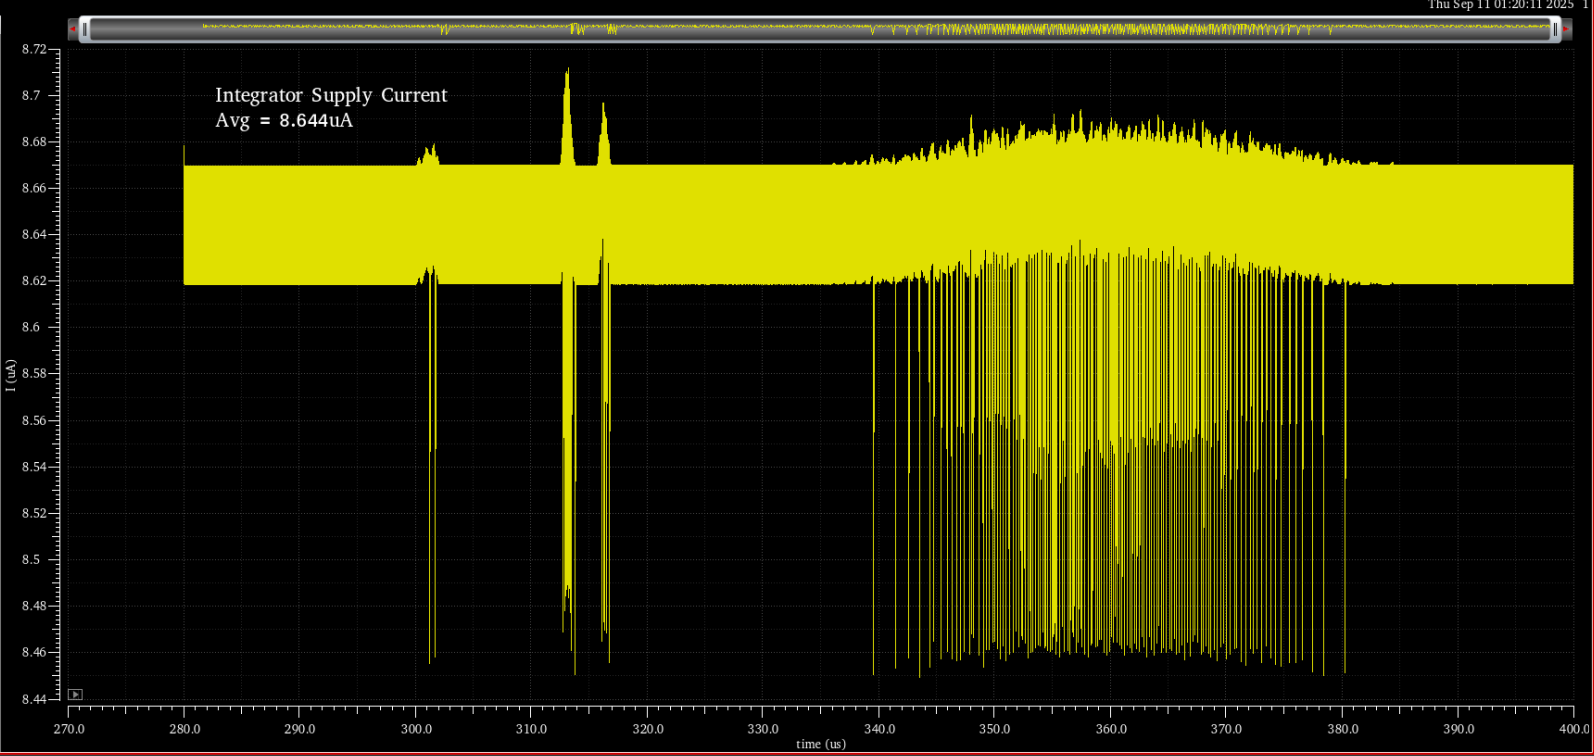

## Input/Output Capacitance

For a 3pF simulated pad capacitance the feedback fraction is
$$ \beta = \frac{Z_{in}}{(Z_{in}+Z_{f})}= \frac{50fF}{50fF+3pF}= 0.016 $$

This is fine for the closed loop gain:
$$ A_{CL}= \frac{A_{O}}{1+\beta A_{O}}= \frac{480}{1+0.016\cdot 480}= 54 $$

But a problem for the GBW:
The unity gain frequency of the opamp is 23.3MHz.
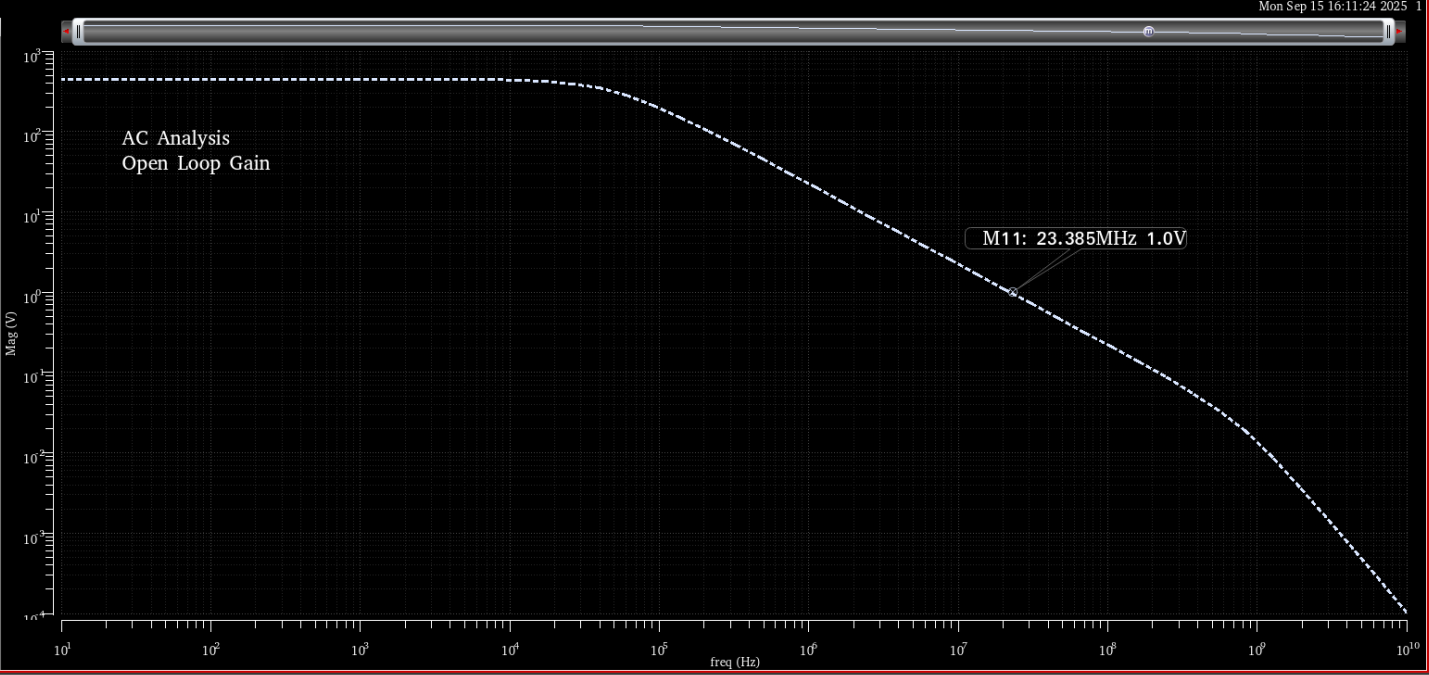

The unity gain closed loop frequency will be set by:
$$f_{u, CL}= \beta \cdot f_{u, O}= 0.016 \cdot 23.3MHz = 372kHz$$
Which means a rise time of
$$ t_r = \frac{0.35}{f_{u, CL}}$$

For rise time of 20ns, this would require a $f_{u, CL}=1GHz$



## Integrator Spy Point


PMOS source follower with 5uA bias current. All W/L= 1.33u/280n. The spy point is the integrator output shifted up by 665mV:

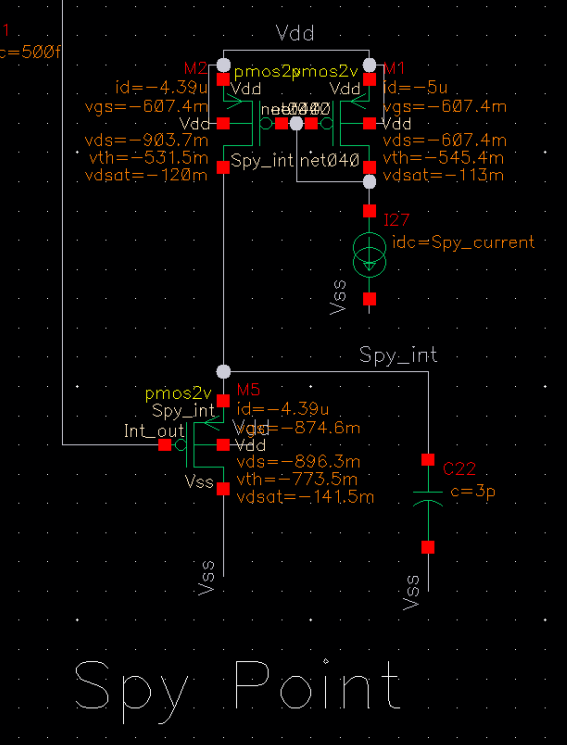
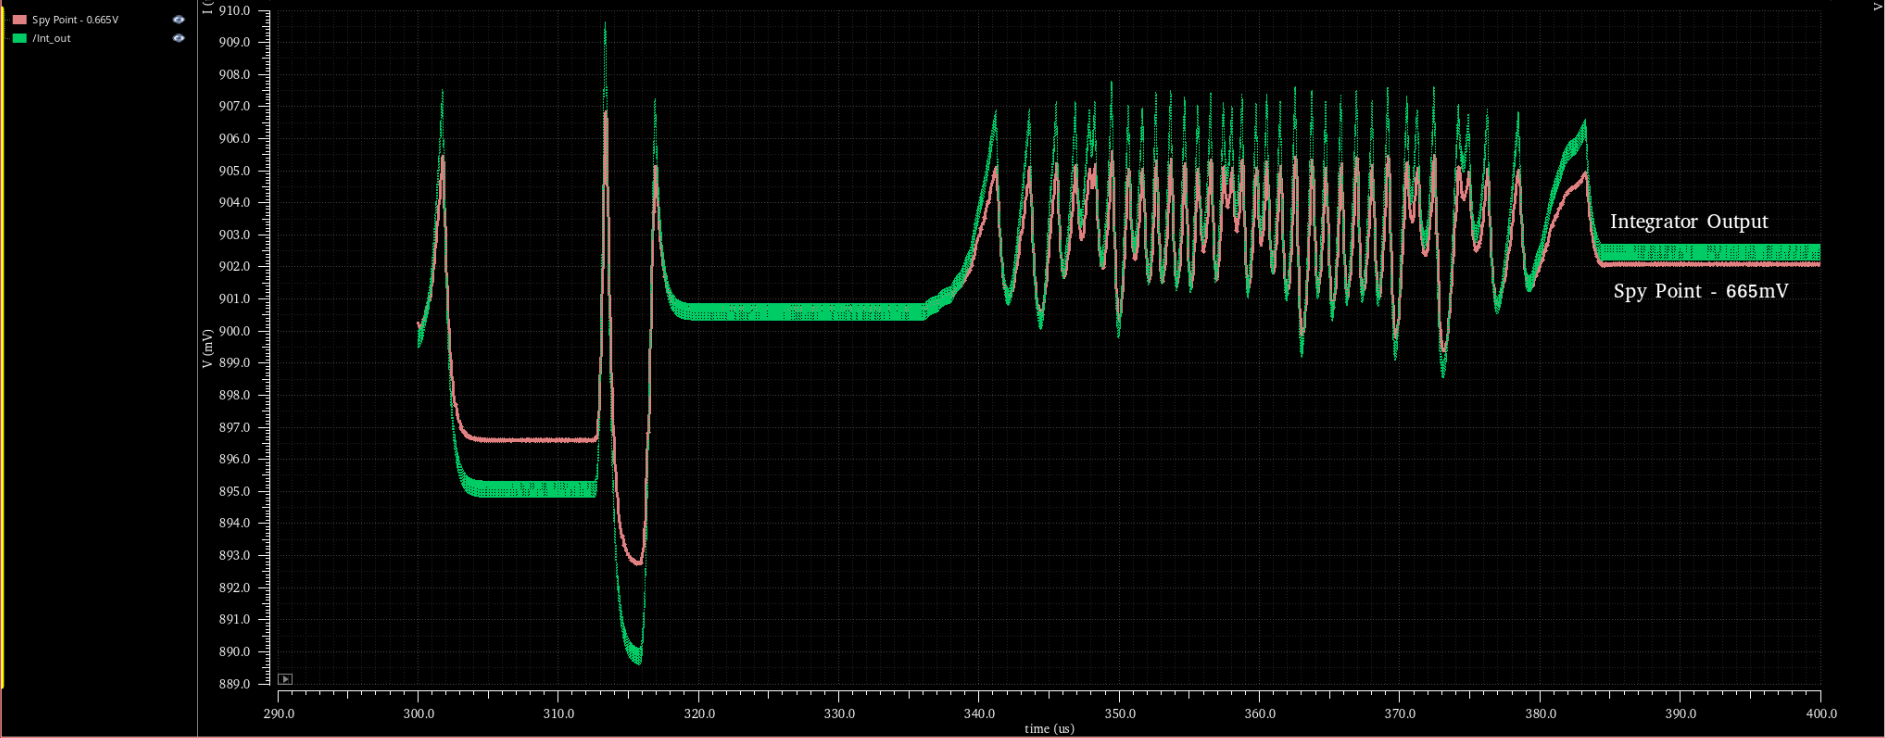



The small signal gain is 0.739

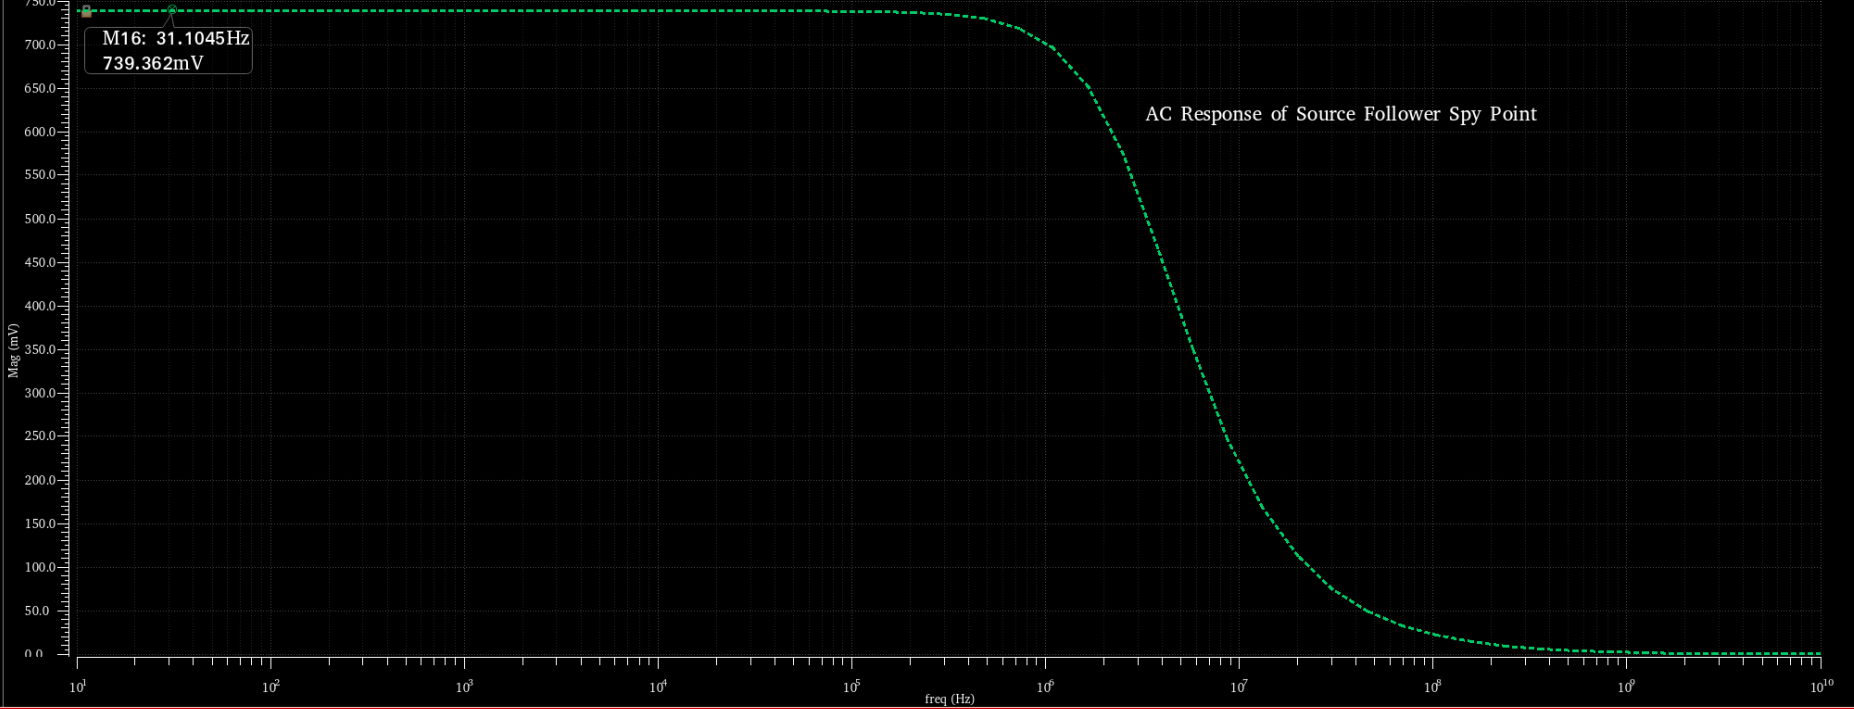


## Power Supply Decoupling

## Voltage References

Band gap reference circuit taken from CMOS Circuit Design, Layout, and Simulation by R. Jacob Baker.

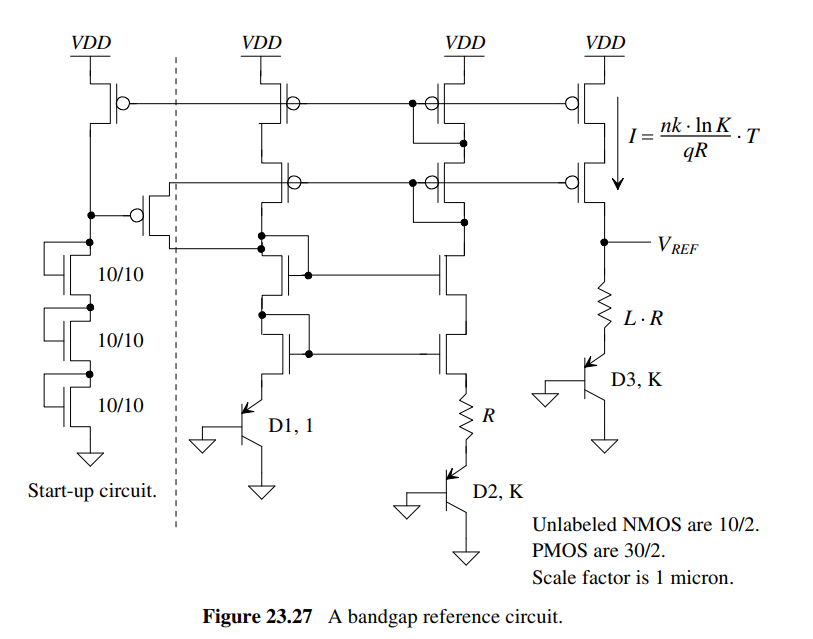

The output voltage is given by:
$$ V_{REF} = V_{D3} + I \cdot L \cdot R = V_{D3} + L \cdot n \cdot ln(K)\cdot V_T$$
Where L is the ratio between the two resistors in the circuit, K is the number of diodes in parallel at D2 and D3, V_{D3} is the voltage across D3, n is a shaping factor for the diode's current-voltage curve, and $V_T$ is the thermal voltage of the transistor (kT/q, 26mV at room temp).

The goal of this circuit is for the output voltage to be temperature independent. Differentiating our previous equation and setting it to zero:
$$ \frac{\partial V_{REF}}{∂ T }= 0 = \frac{∂V_{D3}}{∂T}+L\cdot n \cdot ln(K) \cdot \frac{\partial V_{T}}{\partial T}$$

Solving for L gives:
$$ L = -(\frac{∂V_{D3}}{∂T})(\frac{1}{n\cdot ln(K) \cdot \frac{∂V_T}{∂T}})$$

Where the change in thermal voltage as a function of temperature is $0.085mV/C$ and the change in voltage across D3 as a function of temperature is $-1.6mV/C$ (?). If $n=1$ and $K=2$, this gives L=27.16 for an output voltage which is independent of the temperature.

## Allowed Pads
(1) Spy Current Input & Voltage Output
(2) Vref (opamp reference voltage)
(3) Vref_comp (comparator reference voltage)
(4) 1 pad for all current & voltage biasing

Voltages/Current I need:
(1) 16uA to GND
(2) 3uA to GND
(3) 11uA from Vdd
(4) 937mV
(5) 980mV

## Changes to OpAmp

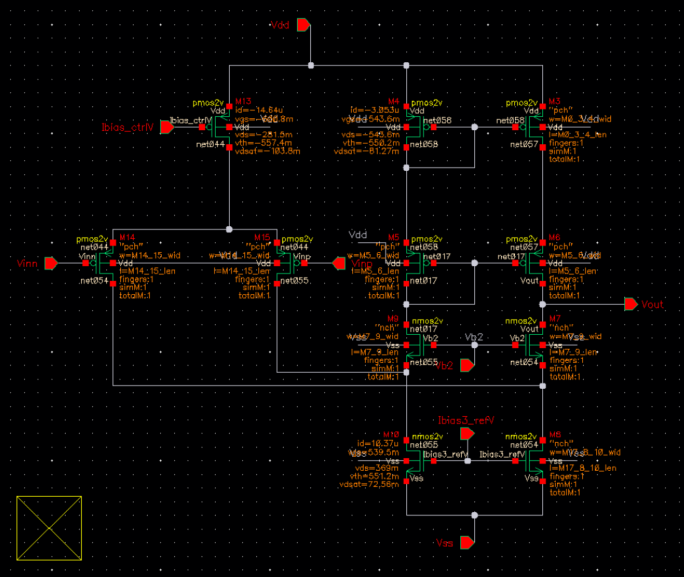

Previously, the gate of M4/M3 was connected to the drain of M5/M6 and the gates of M5/M6 were biased by an external voltage source. The problem that came up was that the biasing circuitry can't drive current, only provides a voltage, which means it can't be connected to anything other than a gate. Therefore, the design was reverted to the original self-biasing of the PMOS tranistors in the output leg. These are the sizes:


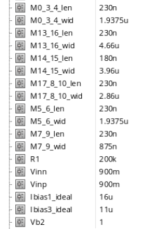


The widths of the output leg transistors are sized so the current through the top part of the leg is 3uA.

Now adjust the bias circuit so Vb2 is 1V

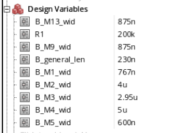
